In [1]:
import sys
import os
import pandas as pd
from datetime import datetime

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Импорты из нашего проекта
from task_agent import TaskEstimatorAgent
from models import Task
from config import Config

In [2]:
import numpy as np

# ===== Spark-блок отключен для локального запуска =====
# from pyspark.sql import SparkSession
# from pyspark.sql import HiveContext
# from pyspark.sql import Window
# from pyspark.sql.functions import col, lit, sum, count, coalesce, when, substring, concat
# from pyspark.sql.types import *
# import pyspark.sql.functions as F
# import pyspark.sql.types as T
#
# spark_application_name = 'strategy_rpp'
# POD_IP = os.environ['POD_IP']
# NS = os.environ['NAMESPACE']
# KEYTAB_USER = "ruaymn2"
# KEYTAB_PATH = "/home/jovyan/ruaymn2.keytab"
# spark = (
#     SparkSession
#     .builder
#     .appName(f"{KEYTAB_USER} notebook")
#     .config("spark.kerberos.keytab", KEYTAB_PATH)
#     .config("spark.kerberos.principal", KEYTAB_USER)
#     .enableHiveSupport()
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda x: "%.3f" % x)
pd.set_option("display.max_colwidth", None)

print("Spark блок отключен. Используем Train_and_test.xlsx")


Spark блок отключен. Используем Train_and_test.xlsx


In [3]:
# spark.stop()  # отключено: локальный запуск без Spark


In [4]:
# Spark-запросы к raw_jira_jira.changeitem отключены для локального прогона


In [5]:
agent = TaskEstimatorAgent()

import requests

response = requests.get(
    f"{Config.LLM_API_URL}/models",
    headers={"Authorization": f"Bearer {Config.API_KEY}"}
)

if response.status_code == 200:
    models = response.json()
    print("Доступные модели:")
    for model in models.get("data", [])[:10]:
        print(f"  - {model['id']}")
else:
    print(f"⚠️ Ошибка получения списка моделей: {response.status_code}")

print(f"\nАгент инициализирован")
print(f"Аналитиков: {len(Config.ANALYSTS)}")
print(f"Модель оценки: {Config.ESTIMATION_MODEL}")


Доступные модели:
  - ultra-coder
  - qwen3-coder-480b-a35b-instruct-fp8
  - confluence-agent
  - vision-instruct
  - qwen3-vl-30b-a3b-instruct
  - file2text-converter-model
  - next-thinking
  - qwen3-next-80b-a3b-thinking
  - next-instruct
  - qwen3-next-80b-a3b-instruct

Агент инициализирован
Аналитиков: 4
Модель оценки: qwen3-next-80b-a3b-thinking


In [6]:
# Загрузка задач из Excel вместо Spark
xlsx_candidates = [
    "Train_and_test.xlsx",
    os.path.join("..", "Train_and_test.xlsx"),
]

xlsx_path = next((p for p in xlsx_candidates if os.path.exists(p)), None)
if not xlsx_path:
    raise FileNotFoundError("Нет")

tasks_df = pd.read_excel(xlsx_path, sheet_name=0)

# Лёгкая очистка
for col in ["Summary", "Description", "Labels", "Assignee", "Наименование системы", "Key"]:
    if col in tasks_df.columns:
        tasks_df[col] = tasks_df[col].fillna("")

tasks_df = tasks_df[tasks_df["Summary"].astype(str).str.strip() != ""].copy()

print(f"Загружено {len(tasks_df)} задач из {xlsx_path}")
print(tasks_df[["Key", "Summary", "Story Points"]].head(5))

Загружено 50 задач из ../Train_and_test.xlsx
           Key  \
0  CMSYS-27050   
1  CMSYS-26830   
2  CMSYS-26829   
3  CMSYS-26795   
4  CMSYS-26777   

                                                             Summary  \
0  Оценка рисков отсутствия проверки лимитов для регулярных платежей   
1                                               Стратегия LS: 2 этап   
2      Cтратегия LS 2026. Декомпозиция транз активности по продуктам   
3                                     Презентация по "Знаки внимани"   
4             Написать скрипт для распределения платежей из реестров   

   Story Points  
0             3  
1             3  
2             2  
3             2  
4             3  


In [7]:
# Преобразование DataFrame в список объектов Task

def parse_labels(raw):
    if raw is None:
        return []
    if isinstance(raw, list):
        return [str(x).strip() for x in raw if str(x).strip()]
    text = str(raw).strip()
    if not text:
        return []
    text = text.replace(";", ",")
    return [x.strip() for x in text.split(",") if x.strip()]


def row_to_task(row):
    issue_key = str(row.get("Key", "")).strip()
    project_key = issue_key.split("-")[0] if "-" in issue_key else "CMSYS"
    issue_num = issue_key.split("-")[-1] if "-" in issue_key else issue_key

    created = row.get("Created", "")
    if hasattr(created, "isoformat"):
        creation_date = str(created)
    else:
        creation_date = str(created) if created is not None else ""

    return Task(
        issue_id=issue_key or issue_num or "unknown",
        issue_num=issue_num or "unknown",
        project_key=project_key,
        project_name=str(row.get("Наименование системы", "") or project_key),
        issue_type="User Story",
        issue_summary=str(row.get("Summary", "")),
        creation_date=creation_date,
        current_assignee=str(row.get("Assignee", "") or "") or None,
        epic_issue_id=None,
        labels=parse_labels(row.get("Labels", "")),
        description=str(row.get("Description", "") or ""),
    )

records = tasks_df.to_dict(orient="records")
tasks = [row_to_task(r) for r in records]

print(f"Преобразовано {len(tasks)} задач в объекты Task")
print("\nПримеры задач:")
for i, task in enumerate(tasks[:3]):
    print(f"  {i+1}. {task.issue_summary} ({task.issue_type})")


Преобразовано 50 задач в объекты Task

Примеры задач:
  1. Оценка рисков отсутствия проверки лимитов для регулярных платежей (User Story)
  2. Стратегия LS: 2 этап (User Story)
  3. Cтратегия LS 2026. Декомпозиция транз активности по продуктам (User Story)


In [10]:
print("Тестирование оценки задачи...")
test_task = tasks[4]

print(f"Задача: {test_task.issue_summary}")
print(f"Описание: {test_task.description[:2000]}...")

try:
    estimated_task = agent.estimate_task(test_task)
    print(f"\nОценка выполнена успешно:")
    print(f"  Сторипоинты: {estimated_task.estimated_story_points}")
    print(f"  Сложность: {estimated_task.complexity_score}")

    prioritized_task = agent.prioritize_task(estimated_task)
    print(f"\nПриоритезация:")
    print(f"  Приоритет: {prioritized_task.priority_score}")
    print(f"  Бизнес-ценность: {prioritized_task.business_value}")
    print(f"  Срочность: {prioritized_task.urgency_score}")

except Exception as e:
    print(f"Ошибка при оценке: {e}")


Тестирование оценки задачи...
Задача: Написать скрипт для распределения платежей из реестров
Описание: *Заказчик:* Макс Бусыгин 
*Суть задачи:* 
Сформировать распределение платежей из реестров 

Описание: 
Сейчас часть платежей отправляется в реестрах. CIB и Ритейл вместе. Важно научиться их распределять для правильной аллокации расходов. 


*Дедлайн: -* ...

Оценка выполнена успешно:
  Сторипоинты: 1.0
  Сложность: 2

Приоритезация:
  Приоритет: 18.0
  Бизнес-ценность: 1.0
  Срочность: 1.0


In [11]:
print("Планирование спринта...")
print(f"Обработка {len(tasks)} задач...")

try:
    sprint_plan = agent.plan_sprint(tasks[:10])

    print(f"\nСпринт запланирован успешно:")
    print(f"  Всего задач: {len(sprint_plan.sprint_tasks)}")
    print(f"  Общие сторипоинты: {sprint_plan.total_story_points:.1f}")

except Exception as e:
    print(f"Ошибка при планировании спринта: {e}")
    import traceback
    traceback.print_exc()


Планирование спринта...
Обработка 50 задач...
Rejected 0 tasks with SP <=0: []

Спринт запланирован успешно:
  Всего задач: 10
  Общие сторипоинты: 28.0


Анализ спринта:
Средние значения:
  Сторипоинты: 2.80
  Приоритет: 53.00
  Бизнес-ценность: 6.30

📋 Топ-5 задач по приоритету:
  Оценка рисков отсутствия проверки лимитов для регулярных платежей (79.0) - analyst_1
  Стратегия LS: 2 этап (79.0) - analyst_2
  Сегментация потенциальных клиентов ЕК (79.0) - analyst_3
  Роадмап спецсчета (79.0) - analyst_4
  Стратегия LS 2026. Пассивы и сегментация (70.0) - analyst_1


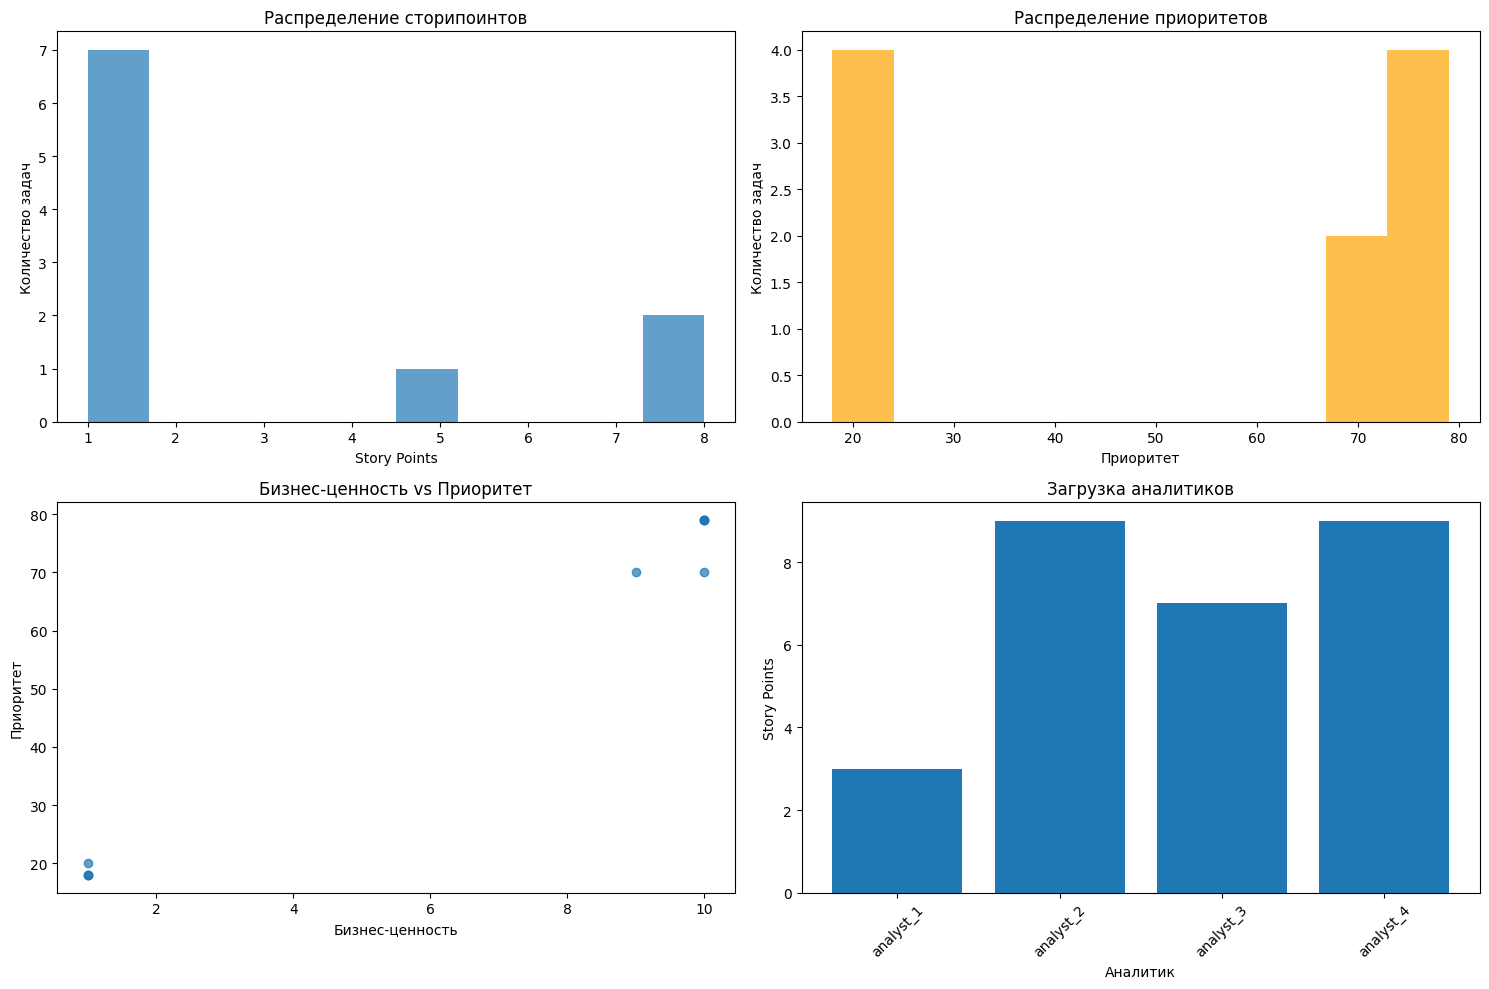


Результаты сохранены в sprint_plan_20260217_232120.csv


In [12]:
# Анализ результатов планирования + оценка качества
if 'sprint_plan' in locals():
    analysis_data = []
    for task in sprint_plan.sprint_tasks:
        analysis_data.append({
            'issue_id': task.issue_id,
            'issue_summary': task.issue_summary,
            'story_points': float(task.estimated_story_points or 0),
            'priority': float(task.priority_score or 0),
            'business_value': float(task.business_value or 0),
            'urgency': float(task.urgency_score or 0),
            'assigned_analyst': task.assigned_analyst or 'Не назначен'
        })

    analysis_df = pd.DataFrame(analysis_data)

    print('Анализ спринта:')
    print(f"  Всего задач: {len(analysis_df)}")
    print(f"  Средний SP: {analysis_df['story_points'].mean():.2f}")

    # Визуализация: только распределение story points
    try:
        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        overall_sp = analysis_df['story_points'].value_counts().sort_index()
        axes[0].bar(overall_sp.index.astype(str), overall_sp.values, color='#4C78A8', alpha=0.9)
        axes[0].set_title('Распределение Story Points (в целом)')
        axes[0].set_xlabel('Story Points')
        axes[0].set_ylabel('Количество задач')

        analyst_sp = (
            analysis_df
            .pivot_table(index='assigned_analyst', columns='story_points', values='issue_id', aggfunc='count', fill_value=0)
            .sort_index(axis=1)
        )
        analyst_sp.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
        axes[1].set_title('Распределение Story Points по аналитикам')
        axes[1].set_xlabel('Аналитик')
        axes[1].set_ylabel('Количество задач')
        axes[1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    except ImportError:
        print('Визуализация недоступна (установите matplotlib)')

    # Оценка качества: сравнение с эталонными Story Points из Train_and_test.xlsx
    if 'tasks_df' in locals() and {'Key', 'Story Points'}.issubset(tasks_df.columns):
        quality_df = analysis_df.merge(
            tasks_df[['Key', 'Story Points']].rename(columns={'Key': 'issue_id', 'Story Points': 'actual_story_points'}),
            on='issue_id',
            how='left'
        )

        quality_df['actual_story_points'] = pd.to_numeric(quality_df['actual_story_points'], errors='coerce')
        quality_df['story_points'] = pd.to_numeric(quality_df['story_points'], errors='coerce')
        quality_df = quality_df.dropna(subset=['actual_story_points', 'story_points']).copy()

        if not quality_df.empty:
            abs_err = (quality_df['story_points'] - quality_df['actual_story_points']).abs()
            mae = abs_err.mean()
            rmse = ((quality_df['story_points'] - quality_df['actual_story_points']) ** 2).mean() ** 0.5
            exact_acc = (quality_df['story_points'] == quality_df['actual_story_points']).mean()
            within_1 = (abs_err <= 1).mean()

            print('
Качество оценки Story Points (по эталону из Excel):')
            print(f'  MAE: {mae:.3f}')
            print(f'  RMSE: {rmse:.3f}')
            print(f'  Exact match: {exact_acc:.1%}')
            print(f'  Within ±1 SP: {within_1:.1%}')

            confusion = pd.crosstab(
                quality_df['actual_story_points'],
                quality_df['story_points'],
                rownames=['Actual SP'],
                colnames=['Predicted SP'],
                dropna=False
            )
            print('
Confusion matrix:')
            print(confusion)

            quality_df['abs_error'] = abs_err
            print('
Топ-5 самых больших ошибок:')
            print(
                quality_df.sort_values('abs_error', ascending=False)
                [['issue_id', 'issue_summary', 'actual_story_points', 'story_points', 'abs_error']]
                .head(5)
                .to_string(index=False)
            )
        else:
            print('
Качество: нет пересечения задач с эталонными Story Points.')

    output_file = f"sprint_plan_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    analysis_df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"
Результаты сохранены в {output_file}")
